In [1]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from src.dataset import MRIDataset, load_subsets
from src.tumor_detector import TumorDetector
import src.metrics as metrics

C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_root = r"C:\Users\yuval\.cache\kagglehub\datasets\mateuszbuda\lgg-mri-segmentation\versions\2\kaggle_3m"
dataset = MRIDataset(dataset_root, limit=None)

# load the test dataset
_, _, test_dataset = load_subsets(dataset, test=True)

# create dataloader
batch_size = 16
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
print(f"Loaded {len(test_dataset)} samples for testing.")

Loaded 392 samples for testing.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model = TumorDetector().to(device)
state_dict = torch.load(r'models/brain_tumor_model_v5/brain_tumor_model_v5.pth', weights_only=True)
model.load_state_dict(state_dict)
print(f"model state dict loaded")


cuda
model state dict loaded


In [4]:
batches_to_show = [13]
confusion_matrix = metrics.build_confusion_matrix()

# Testing
model.eval()
avg_test_dice = 0

saved_samples = [] # storing samples to visualize in the next cell
saved_false_negatives = [] # storing all FN's to visualize in the next cell
with torch.no_grad():
    # iterate batch wise
    for i, (images, gts) in enumerate(test_loader):
        images, gts = images.to(device), gts.to(device)

        with torch.amp.autocast('cuda'):
            batch_predictions, batch_logits = model.predict(images, decision_thresh=0.7)

        # iterate scan wise
        for s in range(images.size(0)):
            prediction = batch_predictions[s]
            logits = batch_logits[s]
            gt = gts[s]

            # calc metrics
            dice = metrics.dice_score(prediction, gt)
            avg_test_dice += dice
            pred_status = metrics.conf_mat(dice, prediction, gt, confusion_matrix, dice_thresh=0.5)
            if pred_status == 'FN':
                saved_false_negatives.append(
                    {
                        'image': images[s].cpu(),
                        'gt': gt.cpu(),
                        'prediction': prediction.cpu(),
                        'logits': logits.cpu(),
                        'batch': i
                    }
                )

        if i in batches_to_show: # storing the 'batches_to_show' to visualize in the next cell
            saved_samples.append(
                {
                  'images': images.cpu(),
                  'gts': gts.cpu(),
                  'predictions': batch_predictions.cpu(),
                  'logits': batch_logits.cpu()
                }
            )

avg_test_dice /= len(test_dataset)

# final summary
print(f"Testing Complete.")
print(f"{len(test_dataset)} scans")
print(f"Avg Dice: {avg_test_dice:.4f}")
print(f"Confusion Matrix: {confusion_matrix}, {sum(confusion_matrix.values())}")
confusion_matrix_norm = {k: v / len(test_dataset) for k, v in confusion_matrix.items()}
print(f"Confusion Matrix Norm: {confusion_matrix_norm}, {sum(confusion_matrix_norm.values())}")
print(f"Accuracy : {metrics.accuracy(confusion_matrix):.4f}")
print(f"Precision: {metrics.precision(confusion_matrix):.4f}")
print(f"Recall   : {metrics.recall(confusion_matrix):.4f}")
print(f"F1-score : {metrics.f1_score(confusion_matrix):.4f}")

Testing Complete.
392 scans
Avg Dice: 0.8764
Confusion Matrix: {'TP': 113, 'TN': 243, 'FP': 22, 'FN': 14}, 392
Confusion Matrix Norm: {'TP': 0.288265306122449, 'TN': 0.6198979591836735, 'FP': 0.05612244897959184, 'FN': 0.03571428571428571}, 1.0
Accuracy : 0.9082
Precision: 0.8370
Recall   : 0.8898
F1-score : 0.8626


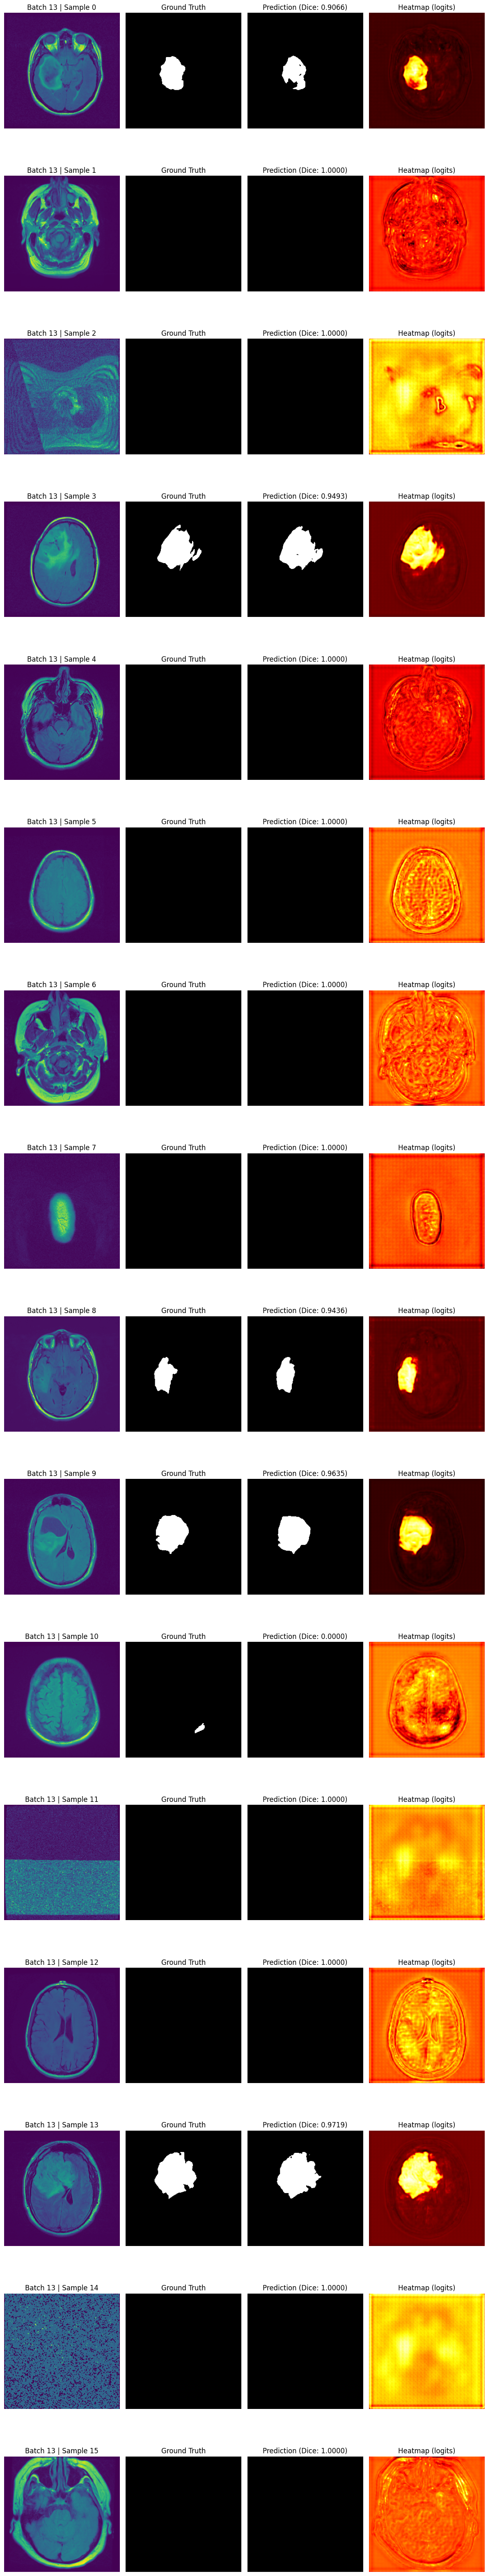

In [5]:
# Visualize a batch
if saved_samples:
    total_samples = len(saved_samples) * batch_size
    fig, axes = plt.subplots(total_samples, 4, figsize=(12, 4 * total_samples))
    if total_samples == 1:
        axes = axes.reshape(1, 3)

    plot_row = 0
    for b_idx, batch_data in enumerate(saved_samples):
        for s_idx in range(batch_size):
            # input image
            img = batch_data['images'][s_idx].permute(1, 2, 0)
            axes[plot_row, 0].imshow(img)
            axes[plot_row, 0].set_title(f"Batch {batches_to_show[b_idx]} | Sample {s_idx}")

            # GT
            gt_mask = batch_data['gts'][s_idx].squeeze()
            axes[plot_row, 1].imshow(gt_mask, cmap='gray')
            axes[plot_row, 1].set_title("Ground Truth")

            # prediction
            prediction = batch_data['predictions'][s_idx].squeeze()
            current_dice = metrics.dice_score(prediction, gt_mask)
            axes[plot_row, 2].imshow(prediction, cmap='gray')
            axes[plot_row, 2].set_title(f"Prediction (Dice: {current_dice:.4f})")

            # heatmap
            logits = batch_data['logits'][s_idx].squeeze()
            axes[plot_row, 3].imshow(logits, cmap='hot')
            axes[plot_row, 3].set_title(f"Heatmap (logits)")

            # Turn off axes for the whole row
            for ax in axes[plot_row]:
                ax.axis('off')

            plot_row += 1

    plt.tight_layout()
    plt.show()

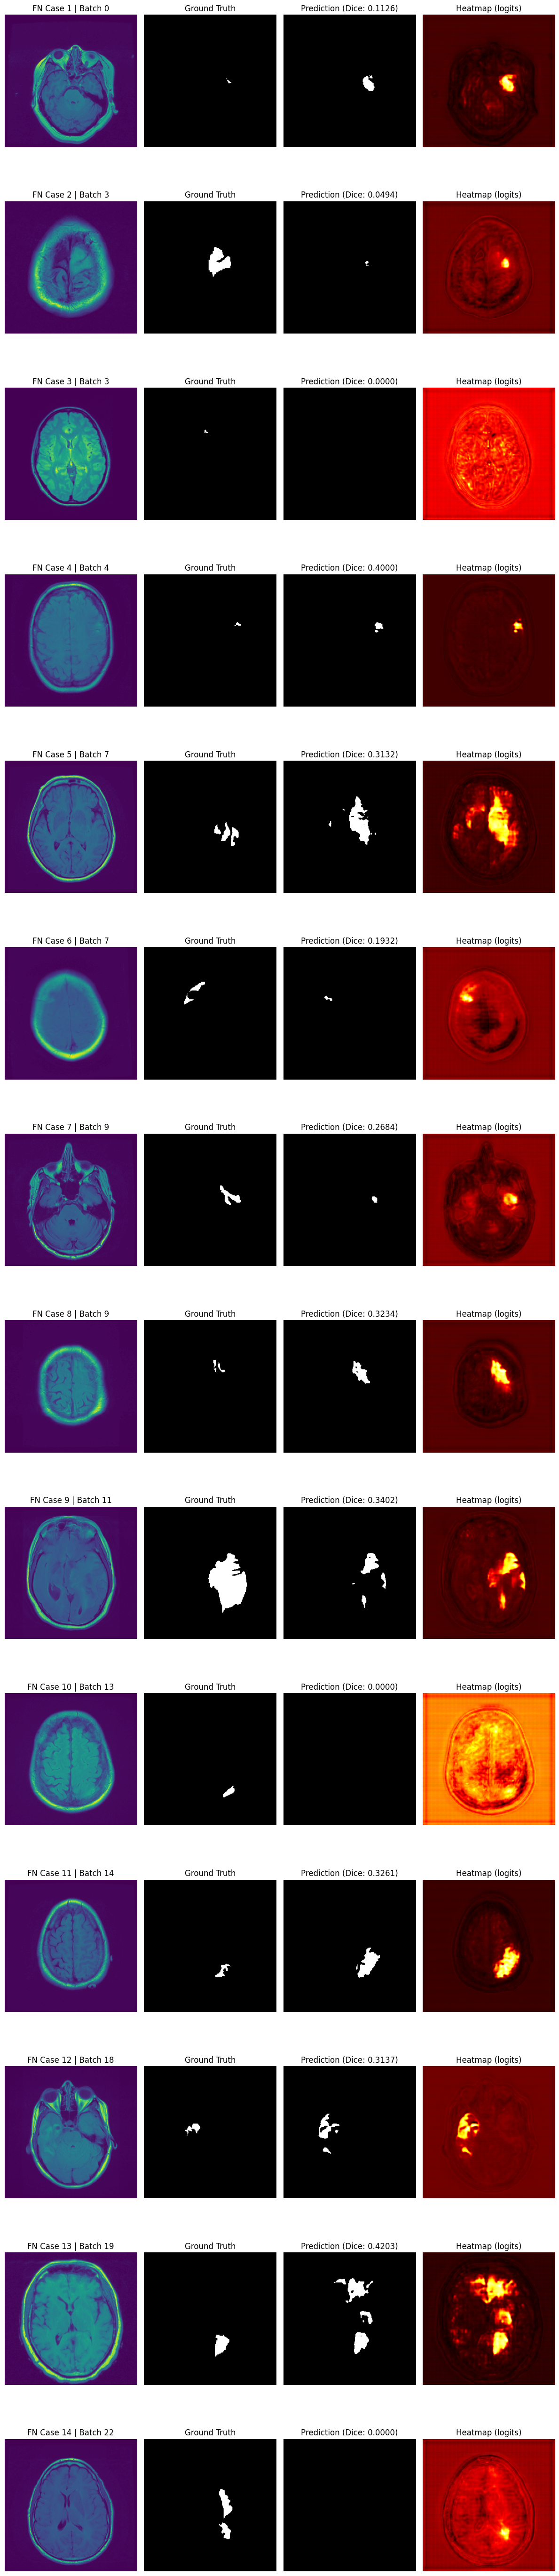

In [6]:
# Visualize FNs
if saved_false_negatives:
    num_fns = len(saved_false_negatives)
    fig, axes = plt.subplots(num_fns, 4, figsize=(12, 4 * num_fns))
    if num_fns == 1:
        axes = axes.reshape(1, 3)

    for i, data in enumerate(saved_false_negatives):
        # input image
        batch = data['batch']
        img = data['image'].permute(1, 2, 0)
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"FN Case {i+1} | Batch {batch}")

        # GT
        gt_mask = data['gt'].squeeze()
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title("Ground Truth")

        # prediction
        prediction = data['prediction'].squeeze()
        current_dice = metrics.dice_score(prediction, gt_mask)
        axes[i, 2].imshow(prediction, cmap='gray')
        axes[i, 2].set_title(f"Prediction (Dice: {current_dice:.4f})")

        # heatmap
        logits = data['logits'].squeeze()
        axes[i, 3].imshow(logits, cmap='hot')
        axes[i, 3].set_title(f"Heatmap (logits)")
        # Clean up
        for ax in axes[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()